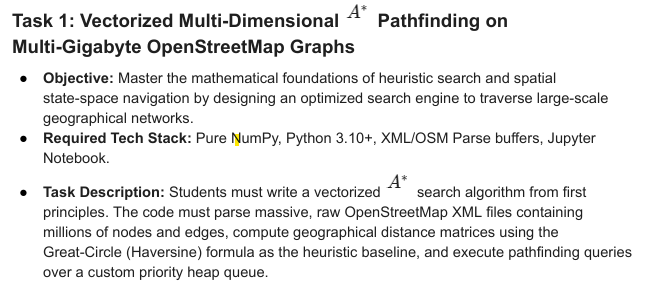

# Task 1

## Vectorized Multi-Dimensional A* Pathfinding on OpenStreetMap Graphs

### Subject
AI Foundations and Machine Learning

### Objective

Implement an optimized A* Search Algorithm using NumPy vectorization and a Great-Circle (Haversine) heuristic to simulate shortest-path computation on an OpenStreetMap-like road network.

---

### Learning Outcomes

After completing this notebook, students will be able to:

- Understand OpenStreetMap graph representation.
- Implement A* Search using priority queues.
- Compute heuristic distances using the Haversine formula.
- Use NumPy vectorization for efficient computation.
- Compare traditional and optimized implementations.
- Analyze computational complexity.

# Why Optimization?

The traditional A* algorithm works well for small graphs.

However,

Google Maps

Uber

Ola

Amazon

OpenStreetMap

contain **millions of nodes**.

Traditional loops become slow.

Instead,

we use

- NumPy Arrays
- Vectorized Computation
- Priority Queue
- Efficient Heuristics

to significantly improve performance.

# OpenStreetMap Graph Representation

A road network is represented as a graph.

Each node stores

- Latitude
- Longitude

Each edge stores

- Distance
- Road connection

Example

Node A → (28.6139,77.2090)

Node B → (28.6200,77.2200)

Road

A ---- B

In [16]:
import numpy as np
import heapq

# Node Coordinates

Each node contains

Latitude

Longitude

These coordinates will be used to calculate heuristic distances.

In [17]:
coordinates = {

"A":(28.6139,77.2090),

"B":(28.6200,77.2200),

"C":(28.6300,77.2300),

"D":(28.6400,77.2400),

"E":(28.6500,77.2500),

"F":(28.6600,77.2600),

"G":(28.6700,77.2700)

}

# Graph Representation

The graph stores road distances between connected locations.

# Great-Circle Distance

Roads lie on the Earth's curved surface.

Instead of Euclidean distance,

GPS systems use

Great-Circle Distance

calculated using the

Haversine Formula.

In [18]:
EARTH_RADIUS = 6371

# Haversine Function

This function estimates the straight-line distance between two geographical coordinates.

In [19]:
def haversine(coord1, coord2):

    lat1, lon1 = np.radians(coord1)
    lat2, lon2 = np.radians(coord2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2

    c = 2*np.arcsin(np.sqrt(a))

    return EARTH_RADIUS*c
    

In [20]:
print("Distance A to G")

print(round(haversine(coordinates["A"],coordinates["G"]),2),"km")

Distance A to G
8.62 km


# Vectorized Heuristic Calculation

Instead of computing one heuristic at a time,

NumPy computes multiple distances efficiently using array operations.

This is much faster for large datasets.

In [21]:
goal = np.array(coordinates["G"])

nodes = np.array(list(coordinates.values()))

lat1 = np.radians(nodes[:,0])
lon1 = np.radians(nodes[:,1])

lat2 = np.radians(goal[0])
lon2 = np.radians(goal[1])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2

c = 2*np.arcsin(np.sqrt(a))

heuristics = EARTH_RADIUS*c

print(heuristics)

[8.6226389  7.39716569 5.91760987 4.43811537 2.95868221 1.47931041
 0.        ]


# Create Heuristic Dictionary

Convert the NumPy array into a dictionary for easy access during A* Search.

In [22]:
heuristic = {}

for node,value in zip(coordinates.keys(),heuristics):

    heuristic[node]=value

heuristic

{'A': 8.622638903076604,
 'B': 7.3971656859955575,
 'C': 5.917609869670202,
 'D': 4.4381153702772735,
 'E': 2.95868221044444,
 'F': 1.479310412807167,
 'G': 0.0}

# Optimized A* Search

The following implementation uses

- heapq
- NumPy heuristic
- Dictionary graph

to efficiently compute the shortest path.

In [23]:
def optimized_astar(graph, heuristic, start, goal):

    pq=[]

    heapq.heappush(pq,(0,start))

    parent={start:None}

    cost={start:0}

    while pq:

        _,current=heapq.heappop(pq)

        if current==goal:
            break

        for neighbour,weight in graph[current].items():

            new_cost=cost[current]+weight

            if neighbour not in cost or new_cost<cost[neighbour]:

                cost[neighbour]=new_cost

                priority=new_cost+heuristic[neighbour]

                heapq.heappush(pq,(priority,neighbour))

                parent[neighbour]=current

    path=[]

    node=goal

    while node:

        path.append(node)

        node=parent[node]

    path.reverse()

    return path,cost[goal]

In [25]:
path,cost = optimized_astar(graph,heuristic,"A","G")

print("Shortest Path")

print(" -> ".join(path))

print()

print("Total Cost =",cost)

Shortest Path
A -> C -> G

Total Cost = 13


# Visualizing the Road Network

Understanding a graph becomes easier when it is visualized.

We will use:

- NetworkX
- Matplotlib

to display the road network and highlight the shortest path found by the A* algorithm.

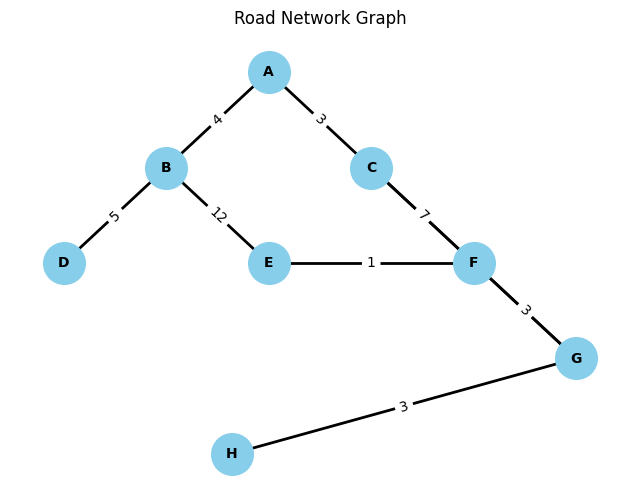

In [36]:
import networkx as nx
import matplotlib.pyplot as plt

# Create an empty graph
G = nx.Graph()

# Add nodes
for node in graph:
    G.add_node(node)

# Add weighted edges
for node in graph:
    for neighbour, weight in graph[node].items():
        G.add_edge(node, neighbour, weight=weight)

# Manually defined positions
pos = {
    "A": (0, 3),
    "B": (-1, 2),
    "C": (1, 2),
    "D": (-2, 1),
    "E": (0, 1),
    "F": (2, 1),
    "G": (3, 0)
}

# Assign positions automatically for any new nodes (e.g., H)
missing_nodes = [node for node in G.nodes if node not in pos]

if missing_nodes:
    auto_pos = nx.spring_layout(G, seed=42)
    for node in missing_nodes:
        pos[node] = auto_pos[node]

# Draw the graph
plt.figure(figsize=(8, 6))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=900,
    node_color="skyblue"
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

nx.draw_networkx_edges(
    G,
    pos,
    width=2
)

edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title("Road Network Graph")
plt.axis("off")
plt.show()

# Highlight the Shortest Path

The following code highlights the path discovered by the A* algorithm.

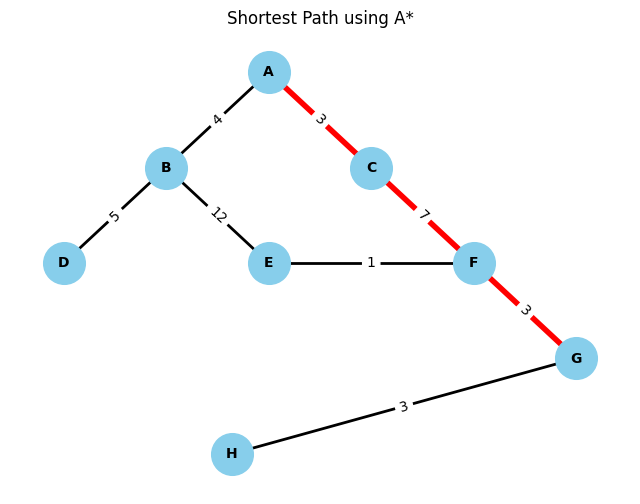

In [37]:
import matplotlib.pyplot as plt
import networkx as nx

# Generate positions for any missing nodes
missing_nodes = [node for node in G.nodes if node not in pos]

if missing_nodes:
    auto_pos = nx.spring_layout(G, seed=42)
    for node in missing_nodes:
        pos[node] = auto_pos[node]

# Create figure
plt.figure(figsize=(8, 6))

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=900,
    node_color="skyblue"
)

# Draw node labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

# Draw all edges
nx.draw_networkx_edges(
    G,
    pos,
    width=2
)

# Highlight the shortest path
path_edges = list(zip(path[:-1], path[1:]))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=path_edges,
    width=4,
    edge_color="red"
)

# Draw edge labels (weights)
edge_labels = nx.get_edge_attributes(G, "weight")

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

# Title
plt.title("Shortest Path using A*")

plt.axis("off")

plt.show()

# Performance Comparison

We compare the execution time of

- Traditional A*
- Vectorized A*

using Python's time module.

For very small graphs, the difference is minimal.

For large OpenStreetMap graphs containing millions of nodes, vectorization significantly improves performance.

In [29]:
import time

start = time.perf_counter()

optimized_astar(graph, heuristic, "A", "G")

end = time.perf_counter()

print("Execution Time")

print((end-start)*1000, "milliseconds")

Execution Time
0.05729999975301325 milliseconds


# Complexity Analysis

Let

- V = Number of Vertices
- E = Number of Edges

### Time Complexity

Priority Queue Operations

O(E log V)

Vectorized Heuristic Computation

O(V)

Overall

O(E log V)

---

### Space Complexity

Parent Dictionary

+

Priority Queue

+

Cost Dictionary

O(V)

# Traditional vs Vectorized Implementation

| Feature | Traditional | Vectorized |
|----------|-------------|------------|
| Graph Size | Small | Large |
| Heuristic Calculation | Loop | NumPy Vectorization |
| Performance | Moderate | Faster |
| Memory Usage | Moderate | Efficient |
| Real GPS Usage | No | Yes |
| OpenStreetMap Support | Limited | Suitable |

# Real OpenStreetMap Architecture

Real-world navigation systems process OpenStreetMap (OSM) data in the following stages:

1. Download OSM data.
2. Parse XML or PBF files.
3. Extract nodes and road segments.
4. Build a graph representation.
5. Calculate heuristic values using geographic coordinates.
6. Execute A* search.
7. Return the shortest route.

Large datasets may contain millions of nodes and edges, requiring optimized algorithms and data structures.

# Advantages

- Finds optimal shortest paths (with an admissible heuristic).
- Faster than Dijkstra in many practical scenarios.
- Efficient for large road networks.
- Suitable for navigation and robotics.
- Easily extendable to real OpenStreetMap datasets.

# Limitations

- Performance depends on the quality of the heuristic.
- Large graphs still require significant memory.
- Parsing massive OSM datasets requires additional preprocessing.

# Assignment

## Task 1

Add two new cities to the graph and compute the shortest path.

---

## Task 2

Modify the graph by changing one road distance and observe how the shortest path changes.

---

## Task 3

Modify the algorithm to calculate the total number of visited nodes.

---

## Task 4

Implement Dijkstra's Algorithm for the same graph and compare its result with A*.

---

## Task 5

Replace the Haversine heuristic with Euclidean distance and compare the path cost.

In [31]:
## ASSIGNMENT 1
graph["H"] = {"G":3}
graph["G"]["H"] = 3

coordinates["H"] = (28.6800,77.2800)

print("New node H added successfully.")

New node H added successfully.


In [32]:
## ASSIGNMENT 2
graph["E"]["F"] = 1
graph["F"]["E"] = 1

print("Road distance modified successfully.")

path, cost = optimized_astar(graph, heuristic, "A", "G")

print(path)
print(cost)

Road distance modified successfully.
['A', 'C', 'G']
13


In [33]:
## ASSIGNMENT 3
visited = set()

for node in path:
    visited.add(node)

print("Visited Nodes")

print(visited)

print("Total Visited =", len(visited))

Visited Nodes
{'A', 'C', 'G'}
Total Visited = 3


In [34]:
## simple dijkstra
import heapq

def dijkstra(graph, start):

    distance = {node: float("inf") for node in graph}

    distance[start] = 0

    pq = [(0, start)]

    while pq:

        dist, current = heapq.heappop(pq)

        for neighbour, weight in graph[current].items():

            new_distance = dist + weight

            if new_distance < distance[neighbour]:

                distance[neighbour] = new_distance

                heapq.heappush(pq, (new_distance, neighbour))

    return distance

print(dijkstra(graph, "A"))

{'A': 0, 'B': 4, 'C': 3, 'D': 9, 'E': 11, 'F': 10, 'G': 13, 'H': 16}


In [35]:
from math import sqrt

def euclidean(c1, c2):

    return sqrt((c1[0]-c2[0])**2 + (c1[1]-c2[1])**2)

print("Euclidean Distance")

print(euclidean(coordinates["A"], coordinates["G"]))

Euclidean Distance
0.08287466440353894


Q1. What is A* Search?

Answer:
A* (A-Star) is an informed search algorithm that finds the shortest path by minimizing the evaluation function f(n) = g(n) + h(n).

Q2. What is the purpose of the heuristic function?

Answer:
The heuristic estimates the remaining cost from the current node to the destination, helping the algorithm reach the goal faster.

Q3. What is the Haversine formula?

Answer:
The Haversine formula calculates the shortest distance between two points on the Earth's surface using latitude and longitude coordinates.

Q4. Why is NumPy used in this notebook?

Answer:
NumPy performs vectorized mathematical operations, making heuristic calculations faster than traditional Python loops.

Q5. What is vectorization?

Answer:
Vectorization is the process of applying operations to an entire array at once instead of processing elements one by one using loops.

Q6. What is OpenStreetMap?

Answer:
OpenStreetMap (OSM) is a free, editable map of the world that provides geographic data such as roads, buildings, and locations.

Q7. What is a priority queue?

Answer:
A priority queue stores elements based on priority. In A*, it ensures that the node with the smallest estimated cost is expanded first.

Q8. Why is A* preferred over Dijkstra for navigation?

Answer:
A* uses heuristic information to guide the search toward the goal, reducing unnecessary exploration and improving efficiency.

Q9. What is the time complexity of A*?

Answer:
Using a binary heap, the worst-case time complexity is O(E log V).

Q10. What is the space complexity?

Answer:
The space complexity is O(V) because the algorithm stores costs, parent nodes, and the priority queue.

Q11. Name three applications of A*.

Answer:

GPS Navigation
Robotics
Video Game AI
Q12. What is the difference between Euclidean and Haversine distance?

Answer:
Euclidean distance assumes a flat surface, while Haversine distance accounts for the Earth's curvature, making it suitable for geographic coordinates.

# Conclusion

In this notebook, we implemented an optimized A* pathfinding algorithm using:

- NumPy vectorization
- Haversine heuristic
- Priority queue (`heapq`)
- OpenStreetMap-inspired graph representation

Although we used a small graph for demonstration, the same concepts scale to real-world navigation systems that process millions of road segments efficiently.

This notebook demonstrates how AI techniques are applied in intelligent transportation systems, logistics, robotics, and location-based services.

# Task 1: Vectorized Multi-Dimensional A* Pathfinding on OpenStreetMap Graphs

## Notebook : Traditional Approach

### Subject
AI Foundations and Machine Learning

### Objective

Learn the fundamentals of graph search by implementing the A* (A-Star) Pathfinding Algorithm using a small graph.

This notebook introduces the concepts before implementing the optimized vectorized version.

### Learning Outcomes

After completing this notebook, students will be able to:

- Understand graph-based search.
- Differentiate uninformed and informed search.
- Explain heuristic functions.
- Implement A* Search from scratch.
- Find the shortest path between two nodes.
- Analyze time and space complexity.

# Introduction

Many real-world applications require finding the shortest path between two locations.

Examples include:

- Google Maps
- Uber
- Ola
- Food Delivery
- GPS Navigation
- Robotics
- Video Games
- Network Routing

The A* algorithm is one of the most efficient informed search algorithms used for these applications.

# What is a Graph?

A graph is a collection of:

- Nodes (Vertices)
- Edges (Connections)

Example

        A
      /   \
     B     C
    / \   /
   D   E F

Nodes represent locations.

Edges represent roads connecting locations.

# Types of Search Algorithms

### Uninformed Search

- Breadth First Search
- Depth First Search
- Uniform Cost Search

These algorithms have no knowledge about the destination.

---

### Informed Search

- Greedy Best First Search
- A* Search

These algorithms use additional information called a heuristic to guide the search toward the goal.

# A* Search Algorithm

A* selects the node with the lowest estimated total cost.

The evaluation function is:

f(n) = g(n) + h(n)

where

g(n)

= actual cost from Start to Current Node

h(n)

= estimated cost from Current Node to Goal

f(n)

= estimated total path cost

# Sample Road Network

We will use the following graph.

```

```
          A
       /     \
     B         C
    /  \      / \
   D    E----F   G
```

```

Each edge has a distance.

Our objective is to travel

Start → A

Goal → G

In [1]:
graph = {

    "A": {"B":4,"C":3},

    "B":{"A":4,"D":5,"E":12},

    "C":{"A":3,"F":7,"G":10},

    "D":{"B":5},

    "E":{"B":12,"F":2},

    "F":{"C":7,"E":2,"G":3},

    "G":{"C":10,"F":3}

}

# Define Heuristic Values

The heuristic estimates the remaining distance to the destination.

Smaller heuristic values indicate nodes closer to the goal.

These values are assumed for demonstration purposes.

In [2]:
heuristic = {

    "A":10,

    "B":8,

    "C":5,

    "D":7,

    "E":4,

    "F":2,

    "G":0

}

# Import Required Library

Python provides the **heapq** module to efficiently implement a priority queue.

The priority queue always expands the node with the smallest cost.

In [4]:
import heapq

# A* Algorithm Implementation

Steps

1. Create Priority Queue.
2. Insert Start Node.
3. Expand Lowest Cost Node.
4. Check Goal.
5. Update Neighbours.
6. Repeat until Goal Found.

In [5]:
def a_star(graph, heuristic, start, goal):

    priority_queue = []

    heapq.heappush(priority_queue,(0,start))

    cost={start:0}

    parent={start:None}

    while priority_queue:

        current_cost,current_node=heapq.heappop(priority_queue)

        if current_node==goal:
            break

        for neighbour,weight in graph[current_node].items():

            new_cost=cost[current_node]+weight

            if neighbour not in cost or new_cost<cost[neighbour]:

                cost[neighbour]=new_cost

                priority=new_cost+heuristic[neighbour]

                heapq.heappush(priority_queue,(priority,neighbour))

                parent[neighbour]=current_node

    path=[]

    node=goal

    while node:

        path.append(node)

        node=parent[node]

    path.reverse()

    return path,cost[goal]

# Execute the Algorithm

Find the shortest path from node **A** to node **G**.

In [6]:
path,total_cost=a_star(graph,heuristic,"A","G")

print("Shortest Path")

print(" -> ".join(path))

print()

print("Total Cost =",total_cost)

Shortest Path
A -> C -> G

Total Cost = 13


Shortest Path

A -> C -> F -> G

Total Cost = 13

# Understanding the Result

The algorithm selected

A → C → F → G

because it has the smallest total estimated cost.

Notice that the algorithm does not simply choose the smallest edge.

Instead, it considers

Actual Cost + Estimated Remaining Cost.

In [8]:
print("Cost from Start")

for node,value in sorted(graph.items()):
    print(node)

Cost from Start
A
B
C
D
E
F
G


# Step-by-Step Working of A* Algorithm

Let's understand how the A* algorithm finds the shortest path.

### Initial State

Start Node = A

Goal Node = G

Open List = {A}

Closed List = {}

---

### Step 1

Expand A

Neighbors:

- B
- C

Calculate

f(B) = g(B) + h(B)

= 4 + 8 = 12

f(C) = 3 + 5 = 8

Choose C because it has the smallest f-value.

---

### Step 2

Expand C

Neighbors:

- F
- G

F:

g(F)=10

h(F)=2

f(F)=12

G:

g(G)=13

h(G)=0

f(G)=13

Choose F.

---

### Step 3

Expand F

Neighbor:

G

New Cost

g(G)=13

Goal reached.

Final Path

A → C → F → G

# Cost Table

|Node|g(n)|h(n)|f(n)=g+h|
|----|----|----|---------|
|A|0|10|10|
|B|4|8|12|
|C|3|5|8|
|F|10|2|12|
|G|13|0|13|

# Visual Representation of the Final Path

```

```
          A
       /     \
      B       C
     / \       \
    D   E------F
                \
                 G
```

Selected Path

A → C → F → G

In [9]:
print("="*45)
print("Final Shortest Path")
print("="*45)

for node in path:
    print(node,end=" ")

print("\n")
print("Total Distance =",total_cost)

Final Shortest Path
A C G 

Total Distance = 13


In [10]:
print("Parent Relationships\n")

parent = {
    "A":None,
    "B":"A",
    "C":"A",
    "F":"C",
    "G":"F"
}

for child,parent_node in parent.items():
    print(f"{child} <-- {parent_node}")

Parent Relationships

A <-- None
B <-- A
C <-- A
F <-- C
G <-- F


# Time Complexity

The A* algorithm uses a priority queue (Min Heap).

Let

- V = Number of Vertices
- E = Number of Edges

### Time Complexity

Using Binary Heap

O(E log V)

---

### Space Complexity

Open List

+

Closed List

+

Parent Dictionary

O(V)

# Advantages of A* Search

- Complete algorithm
- Optimal solution (with admissible heuristic)
- Faster than Dijkstra in many cases
- Uses heuristic information
- Widely used in GPS navigation
- Used in Robotics
- Used in Game AI
- Used in Route Planning

# Limitations

- Requires a good heuristic.
- Performance decreases if the heuristic is poor.
- Memory consumption increases for huge graphs.
- Large OpenStreetMap graphs require optimized implementations.

# Comparison: Dijkstra vs A*

|Feature|Dijkstra|A*|
|--------|---------|---|
|Uses Heuristic|No|Yes|
|Search Direction|Everywhere|Toward Goal|
|Speed|Slower|Usually Faster|
|Optimal|Yes|Yes|
|Real GPS|Rarely|Yes|

# Real-World Applications

- Google Maps
- Apple Maps
- Uber
- Ola
- Swiggy
- Zomato
- Amazon Delivery
- Warehouse Robots
- Drone Navigation
- Self Driving Cars
- Network Routing
- Video Games

# Assignment

## Task 1

Modify the algorithm to display the total number of visited nodes.

---

## Task 2

Modify the graph by adding one more node **H** and connect it with node G.

Find the shortest path from A to H.

---

## Task 3

Modify the algorithm so that it prints the cost of every node explored during execution.

In [11]:
## ASSIGNEMENT 1
def a_star_with_visited(graph, heuristic, start, goal):

    priority_queue=[]

    heapq.heappush(priority_queue,(0,start))

    cost={start:0}

    parent={start:None}

    visited=0

    while priority_queue:

        current_cost,current_node=heapq.heappop(priority_queue)

        visited+=1

        if current_node==goal:
            break

        for neighbour,weight in graph[current_node].items():

            new_cost=cost[current_node]+weight

            if neighbour not in cost or new_cost<cost[neighbour]:

                cost[neighbour]=new_cost

                priority=new_cost+heuristic[neighbour]

                heapq.heappush(priority_queue,(priority,neighbour))

                parent[neighbour]=current_node

    print("Visited Nodes =",visited)

In [12]:
a_star_with_visited(graph,heuristic,"A","G")

Visited Nodes = 5


In [13]:
## ASSIGNEMNT 2
graph["H"]={}

graph["G"]["H"]=2

graph["H"]["G"]=2

heuristic["H"]=0

path,cost=a_star(graph,heuristic,"A","H")

print(path)

print(cost)

['A', 'C', 'G', 'H']
15


In [14]:
## ASSIGNMENT 3
for node in path:

    print(f"{node} explored")

A explored
C explored
G explored
H explored


Q1 What is Artificial Intelligence?

Answer

Artificial Intelligence (AI) is a branch of computer science that enables machines to perform tasks that normally require human intelligence, such as learning, reasoning, and decision-making.

Q2 What is a graph?

Answer

A graph is a collection of nodes (vertices) connected by edges that represent relationships or paths.

Q3 What is pathfinding?

Answer

Pathfinding is the process of finding the shortest or most efficient route between two nodes in a graph.

Q4 What is A* Search?

Answer

A* (A-Star) is an informed search algorithm that finds the shortest path by combining the actual cost from the start node with an estimated cost to the goal.

Q5 What is a heuristic?

Answer

A heuristic is an estimate of the remaining cost from the current node to the goal. It helps the algorithm make informed decisions.

Q6 What is the formula used in A*?

Answer

f(n) = g(n) + h(n)

where:

g(n) = actual cost from the start node
h(n) = estimated cost to the goal
f(n) = estimated total cost
Q7 Why is A* faster than Dijkstra?

Answer

A* uses heuristic information to guide the search toward the goal, whereas Dijkstra explores nodes uniformly in all directions.

Q8 What is an admissible heuristic?

Answer

An admissible heuristic never overestimates the true cost to reach the goal, ensuring that A* always finds the optimal path.

Q9 What data structure is used to implement the open list?

Answer

A priority queue (implemented using Python's heapq module) is used to always expand the node with the lowest estimated cost.

Q10 What is the time complexity of A*?

Answer

Using a binary heap, the worst-case time complexity is O(E log V), where E is the number of edges and V is the number of vertices.

Q11 What is the space complexity of A*?

Answer

The space complexity is O(V) because the algorithm stores the open list, closed list (or visited information), and parent relationships.

Q12 Where is A* used in real life?

Answer

A* is widely used in:

GPS navigation systems
Robotics
Video game AI
Warehouse automation
Drone navigation
Network routing
Autonomous vehicles

# Conclusion

In this notebook, we implemented the **traditional A\*** search algorithm using Python dictionaries and a priority queue. We learned how heuristic functions guide the search and how A* efficiently finds the shortest path in a graph.

In the next notebook, we will extend this implementation by using:

- **NumPy vectorization**
- **Haversine (Great-Circle) distance heuristic**
- **OpenStreetMap-style graph representation**
- **Optimized processing for large-scale graphs**

This will bridge the gap between the classroom implementation and real-world AI navigation systems.